# Validating `video_timing_qc` on real sessions

Runs the video timing QC and correction on the bottom camera of three public
sessions and checks the result against the Harp camera trigger log
(`Event_94.bin`), which records every trigger and so gives the true time of
every exposure.

| Label | Session | What is wrong |
|---|---|---|
| ok | `behavior_800886_2025-09-03_13-03-45` | nothing |
| harp_glitch | `behavior_809491_2025-10-02_09-23-46` | one Harp value ~983 ms early (row 183624) |
| frame_drops | `behavior_816214_2025-12-02_08-28-39` | 172,631 dropped frames and two glitches |

The CSV correction uses the CSV alone; the trigger log is used only to check
it. Files are downloaded from `s3://aind-open-data` over HTTPS (~150 MB per
session) into `VTQ_CACHE` (default `./video_timing_qc_data`). See
`VIDEO_TIMING_QC_PLAN.md` for the background.

In [1]:
import os
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aind_dynamic_foraging_behavior_video_analysis import video_timing_qc as vtq

S3 = "https://aind-open-data.s3.amazonaws.com"
CACHE = Path(os.environ.get("VTQ_CACHE", "video_timing_qc_data"))
SESSIONS = {
    "ok": "behavior_800886_2025-09-03_13-03-45",
    "harp_glitch": "behavior_809491_2025-10-02_09-23-46",
    "frame_drops": "behavior_816214_2025-12-02_08-28-39",
}


def fetch(key):
    """Return a local copy of an aind-open-data object, downloading once."""
    path = CACHE / key
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print("downloading", key)
        urllib.request.urlretrieve(f"{S3}/{key}", path)
    return path


timing, log = {}, {}
for label, session in SESSIONS.items():
    timing[label] = vtq.load_video_timing(
        fetch(f"{session}/behavior-videos/bottom_camera.csv")
    )
    log[label] = vtq.read_harp_trigger_log(
        fetch(f"{session}/behavior/raw.harp/BehaviorEvents/Event_94.bin")
    )

## 1. Check

`check_video_timing` runs each check, one question each, and
`timing_action` says what the correction will do. A ✗ is a failed check,
with its message.

In [2]:
checks = {label: vtq.check_video_timing(t) for label, t in timing.items()}


def cell(row):
    if row["passed"] is None:
        return "skipped"
    return "✓" if row["passed"] else "✗ " + row["message"]


table = pd.DataFrame({
    label: c.set_index("check").apply(cell, axis=1) for label, c in checks.items()
})
table.loc["action"] = {label: vtq.timing_action(c) for label, c in checks.items()}
table

,ok,harp_glitch,frame_drops
check,,,
no_frames_lost,✓,✓,✗ 172631 frames lost
frame_numbers_increase,✓,✓,✓
camera_time_increases,✓,✓,✓
harp_has_no_glitches,✓,✗ 1 isolated glitches,✗ 2 isolated glitches
harp_evenly_spaced,✓,✓,✓
harp_matches_camera,✓,✓,✗ 172631 steps differ by more than 0.5 frame
video_frame_count,skipped,skipped,skipped
action,use harp as written,fix glitches,re-index


## 2. Correct, and compare with the trigger log

Each session is corrected twice: from the CSV alone, and from the trigger
log. The error columns compare Harp time per row with the trigger-log
correction (true time of each row's exposure):

- `raw_err_max_s`: the CSV as written.
- `exact_err_max_us`: rows the CSV correction re-indexed or left alone.
- `tail_err_max_ms`: rows the CSV never had a trigger for, estimated from
  camera time.

In [3]:
fixed, rows = {}, []
for label, t in timing.items():
    f = vtq.correct_video_timing(t)
    truth = vtq.correct_video_timing(t, trigger_times=log[label])["harp_time"]
    fixed[label] = f
    err = (f["harp_time"] - truth).abs()
    tail = f["harp_source"] == "estimated_camera_fit"
    rows.append({
        "session": label,
        "raw_err_max_s": (t["harp_time_raw"] - truth).abs().max(),
        "exact_err_max_us": err[~tail].max() * 1e6,
        "tail_err_max_ms": err[tail].max() * 1e3 if tail.any() else 0.0,
        **f["harp_source"].value_counts().to_dict(),
    })
summary = pd.DataFrame(rows).set_index("session").fillna(0)
summary.round(4).astype({c: int for c in f["harp_source"].unique()})

,raw_err_max_s,exact_err_max_us,tail_err_max_ms,original,glitch_interpolated,reindexed,estimated_camera_fit
session,,,,,,,
ok,0.0000,0.0,0.000,2672569,0,0,0
harp_glitch,0.9830,0.0,0.000,2566315,1,0,0
frame_drops,345.2603,0.0,0.058,2546,2,2328973,161410


## 3. A Harp glitch

Around the glitch row, the raw Harp step jumps −981 ms then +985 ms while
the camera steps 2 ms. After correction the Harp step matches the camera
(the ±16 µs alternation is Harp's 32 µs clock tick).

        frame_number  harp_time_raw    harp_time          harp_source
183622    1620205256   7156070.9952 7156070.9952             original
183623    1620205257   7156070.9972 7156070.9972             original
183624    1620205258   7156070.0162 7156070.9992  glitch_interpolated
183625    1620205259   7156071.0012 7156071.0012             original
183626    1620205260   7156071.0032 7156071.0032             original


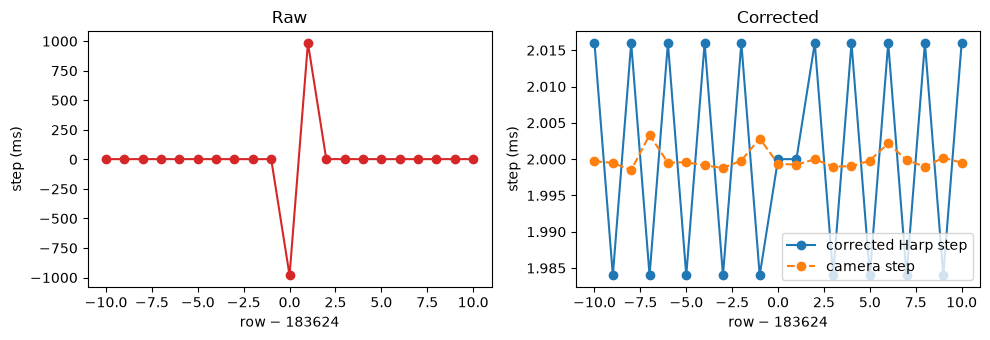

In [4]:
t, f = timing["harp_glitch"], fixed["harp_glitch"]
r = checks["harp_glitch"].set_index("check").loc["harp_has_no_glitches", "rows"][0]
window = slice(r - 10, r + 11)
steps = pd.DataFrame({
    "raw Harp step": t["harp_time_raw"].diff(),
    "corrected Harp step": f["harp_time"].diff(),
    "camera step": t["camera_time"].diff(),
}).iloc[window] * 1e3
steps.index = steps.index - r

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
steps["raw Harp step"].plot(ax=ax[0], marker="o", color="C3")
ax[0].set(title="Raw", xlabel=f"row − {r}", ylabel="step (ms)")
steps[["corrected Harp step", "camera step"]].plot(
    ax=ax[1], marker="o", style=["-", "--"]
)
ax[1].set(title="Corrected", xlabel=f"row − {r}", ylabel="step (ms)")
fig.tight_layout()
columns = ["frame_number", "harp_time_raw", "harp_time", "harp_source"]
print(f[columns].iloc[r - 2:r + 3].to_string(float_format="%.4f"))

## 4. Dropped frames

The first rows after the first drop show the arrival-order pairing: the
frame number skips, but the raw Harp time keeps stepping one frame
interval, so every later row carries the trigger of an earlier frame.
Correction moves each value to the row of its exposure.

In [5]:
t, f = timing["frame_drops"], fixed["frame_drops"]
g = checks["frame_drops"].set_index("check").loc["no_frames_lost", "rows"][0]
columns = ["frame_number", "harp_time_raw", "harp_time", "harp_source"]
print(f[columns].iloc[g - 3:g + 5].to_string(float_format="%.4f"))

      frame_number  harp_time_raw    harp_time harp_source
2543      88760507   1445727.3015 1445727.3015    original
2544      88760508   1445727.3035 1445727.3035    original
2545      88760509   1445727.3055 1445727.3055    original
2546      88760511   1445727.3075 1445727.3095   reindexed
2547      88760512   1445727.3095 1445727.3115   reindexed
2548      88760513   1445727.3115 1445727.3135   reindexed
2549      88760514   1445727.3135 1445727.3155   reindexed
2550      88760515   1445727.3155 1445727.3175   reindexed


Over the whole session, Harp minus camera time (offset removed) should be
flat up to slow clock drift. Raw, it falls by one frame interval per
drop, to −345 s by the end. Corrected, it stays flat, including the last
~5 min of rows the CSV had no trigger for (shaded).

The lower panels compare the two correction methods with the raw trigger
log, read at each row's own exposure (`log[frame_number − first]`):

- **From the CSV** (default): rows the CSV had are exact; the shaded rows
  are estimated from camera time, within ~0.06 ms.
- **From the trigger log** (`trigger_times=log`): every row, shaded ones
  included, is read from the log, so the error is 0 throughout.

The two glitch rows are left out of these panels, because there the log
itself is wrong; both methods replace them with the midpoint of their
neighbours (printed below).

Corrected from the CSV (tail from camera time): max |error| 0.0580 ms
Corrected from the trigger log: max |error| 0.0000 ms

Glitch rows: raw log vs both corrections
             raw log     from CSV     from log
518752  1446830.0162 1446830.9992 1446830.9992
1269769 1448436.0162 1448436.9992 1448436.9992


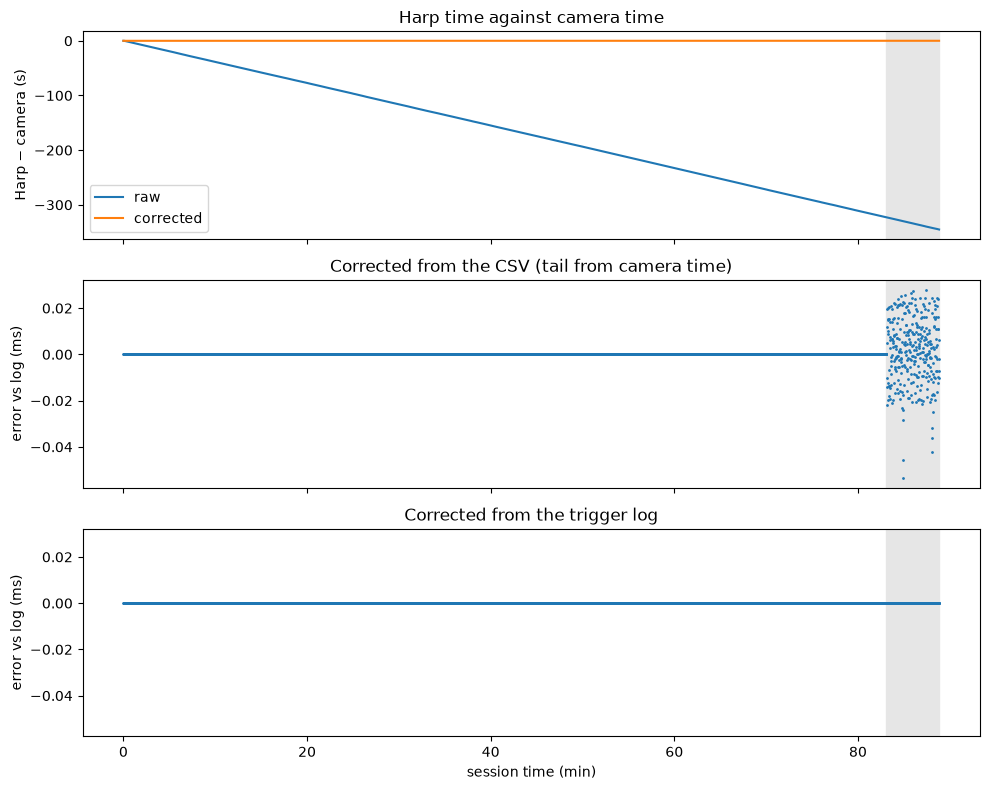

In [6]:
t, f = timing["frame_drops"], fixed["frame_drops"]
from_log = vtq.correct_video_timing(t, trigger_times=log["frame_drops"])
k = (t["frame_number"] - t["frame_number"].iloc[0]).to_numpy()
reference = pd.Series(log["frame_drops"][k], index=t.index)
glitch = f["harp_source"] == "glitch_interpolated"

every = slice(None, None, 500)
minutes = (t["camera_time"] - t["camera_time"].iloc[0]) / 60
offset = t["harp_time_raw"].iloc[0] - t["camera_time"].iloc[0]
tail = f["harp_source"] == "estimated_camera_fit"
tail_start = minutes[tail].iloc[0]

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for series, label in [(t["harp_time_raw"], "raw"), (f["harp_time"], "corrected")]:
    ax[0].plot(minutes[every], (series - t["camera_time"] - offset)[every],
               label=label)
ax[0].set(ylabel="Harp − camera (s)", title="Harp time against camera time")
ax[0].legend()
for a, corrected, title in [
    (ax[1], f, "Corrected from the CSV (tail from camera time)"),
    (ax[2], from_log, "Corrected from the trigger log"),
]:
    error_ms = ((corrected["harp_time"] - reference) * 1e3)[~glitch]
    a.plot(minutes[~glitch][every], error_ms[every], ".", markersize=2)
    a.set(ylabel="error vs log (ms)", title=title)
    print(f"{title}: max |error| {error_ms.abs().max():.4f} ms")
ax[1].sharey(ax[2])
ax[2].set(xlabel="session time (min)")
for a in ax:
    a.axvspan(tail_start, minutes.iloc[-1], color="0.9", zorder=0)
fig.tight_layout()

print()
print("Glitch rows: raw log vs both corrections")
print(pd.DataFrame({
    "raw log": reference[glitch],
    "from CSV": f["harp_time"][glitch],
    "from log": from_log["harp_time"][glitch],
}).to_string(float_format="%.4f"))

## Result

- **ok**: nothing changed (all rows `original`).
- **harp_glitch**: only the glitch row changed, to within 0 µs of the
  trigger log.
- **frame_drops**: raw Harp was up to minutes off. After correction from
  the CSV, re-indexed rows equal the trigger log exactly and estimated
  tail rows are within ~0.06 ms; correcting from the log makes the tail
  exact too. Both glitches were fixed.